# Set up colab gpu runtime env

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-9azlxblm
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-9azlxblm
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


#Utility function

In [72]:
class Utils:
    @staticmethod
    def display_image(image, true_mask, pred_mask=None):
        # Handle tensor inputs: move to CPU, convert to numpy, permute dimensions
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).cpu().numpy()
        if isinstance(true_mask, torch.Tensor):
            true_mask = true_mask.squeeze().cpu().numpy() # Squeeze to (H,W) if (1,H,W)

        f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        ax1.set_title('image')
        ax1.imshow(image)

        ax2.set_title('Groud truth')
        ax2.imshow(true_mask, cmap='gray')

        plt.show()

    @staticmethod
    def display_inference(image, true_mask, pred_mask):
        # Ensure inputs are tensors and handle their display format
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).cpu().numpy()
        if isinstance(true_mask, torch.Tensor):
            true_mask = true_mask.squeeze().cpu().numpy()
        if isinstance(pred_mask, torch.Tensor):
            pred_mask = pred_mask.squeeze().cpu().numpy()

        f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

        ax1.set_title('Original Image')
        ax1.imshow(image)

        ax2.set_title('Ground Truth')
        ax2.imshow(true_mask, cmap='gray')

        ax3.set_title('Predicted Mask')
        ax3.imshow(pred_mask, cmap='gray')

        plt.show()

# Download Dataset

In [2]:
!git clone https://github.com/parth1620/Road_seg_dataset.git

Cloning into 'Road_seg_dataset'...
remote: Enumerating objects: 411, done.
remote: Total 411 (delta 0), reused 0 (delta 0), pack-reused 411 (from 1)
Receiving objects: 100% (411/411), 851.74 MiB | 28.27 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (401/401), done.


In [3]:
import os
import sys

In [4]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

import helper

#Setup Config

In [5]:
CSV_PATH = 'Road_seg_dataset/train.csv'
DATA_DIR = 'Road_seg_dataset'

EPOCHS = 30
LR = 0.001
BATCH_SIZE = 8
IMG_SIZE = 512

ENCODER = 'resnet34'
WEIGHTS =  'imagenet'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
# load dataset with pandas
df = pd.read_csv(CSV_PATH)
df.head()

,images,masks
0,images/17428750_15.png,masks/17428750_15.png
1,images/23279080_15.png,masks/23279080_15.png
2,images/24179185_15.png,masks/24179185_15.png
3,images/24179035_15.png,masks/24179035_15.png
4,images/11128810_15.png,masks/11128810_15.png


In [65]:
# some visualizations

idx = 3
row = df.iloc[idx]

image_path = os.path.join(DATA_DIR, row.images)
mask_path = os.path.join(DATA_DIR, row.masks)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) /255

#we divide mask/255 to change the scale from 0 to 255 to 0 to 1


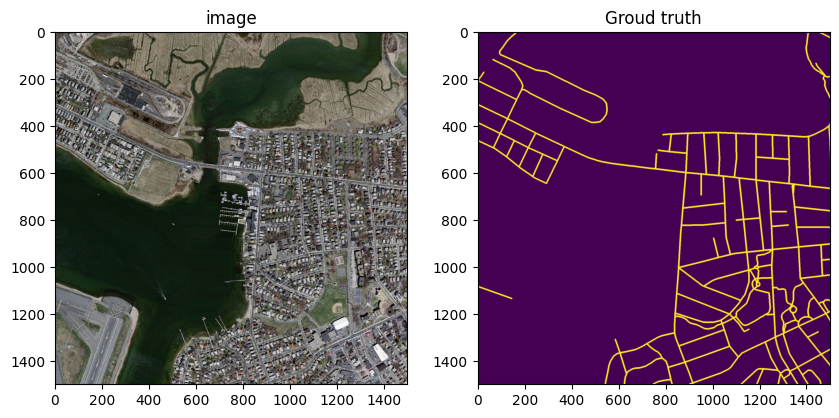

In [66]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.set_title('image')
ax1.imshow(image)

ax2.set_title('Groud truth')
ax2.imshow(mask)

plt.show()

In [9]:
## split the data for training and validation

train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)
print(f'train size : {len(train_df)}, valid size : {len(valid_df)}')


train size : 159, valid size : 40


#Augmentation Functions

In [10]:
import albumentations as A
def get_train_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5)
  ])

def get_valid_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE)
  ])

#Create Custom Dataset

In [41]:
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
  def __init__(self, df, augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    image_path = os.path.join(DATA_DIR, row.images)
    mask_path = os.path.join(DATA_DIR, row.masks)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = np.expand_dims(mask, axis=-1) # (h,w,c)

    if self.augmentations:
      data = self.augmentations(image=image, mask=mask)
      image = data['image']
      mask = data['mask']

    image = np.transpose(image, (2, 0, 1)).astype(np.float32)  #(c,h,w)
    mask = np.transpose(mask, (2, 0, 1)).astype(np.float32) #(c,h,w)
    # Convert image and masl to torch tensor
    image = torch.tensor(image, dtype=torch.float) / 255.0
    mask = torch.tensor(mask, dtype=torch.float) / 255.0
    return image, mask


In [42]:
trainset = SegmentationDataset(train_df, get_train_augs())
validset = SegmentationDataset(valid_df, get_valid_augs())

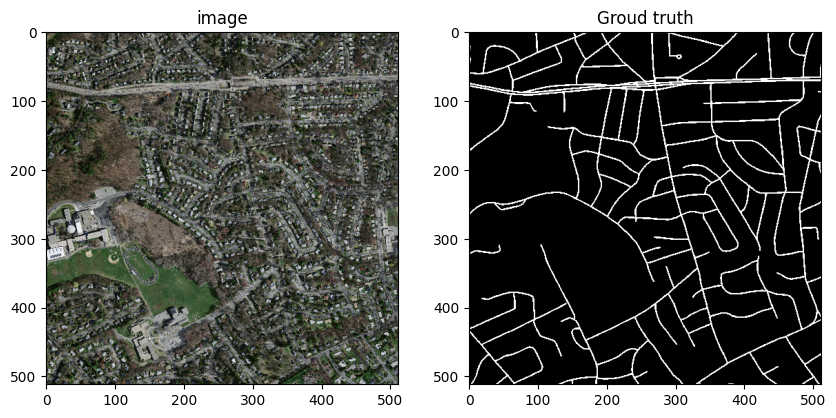

In [74]:
#plot an example for visualization
idx = 15
image, mask =  trainset[idx]
Utils.display_image(image, mask)

#Load dataset into batches


In [14]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)

In [15]:
#print size of the first tensor in trainset

for image, mask in trainloader:
  print(image.shape) # format -> (batch,c,h,w)
  print(mask.shape) # format -> (batch,c,h,w)
  break

torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])


# Create NN  (Segmentation model)

In [16]:
#load UNet architecture
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

from torch import nn

In [29]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel, self).__init__()
    self.backbone = smp.Unet(
        encoder_name=ENCODER,
        encoder_weights=WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None
    )
  def forward(self, images, masks=None):
      logits = self.backbone(images)
      if masks != None:
        loss1 = DiceLoss(mode='binary')(logits, masks)
        loss2 = nn.BCEWithLogitsLoss()(logits, masks)
        return logits, loss1 + loss2

      return logits

In [18]:
model = SegmentationModel()
model.to(DEVICE);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [31]:
# Instantiate the segmentation model.
model = SegmentationModel()
model.to(DEVICE);

#Create Train and Validation Functions

In [32]:

def train_fc(dataloader, model, optimizer):
  model.train()
  total_loss = 0.0
  for images, masks in dataloader:
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()

    logits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

def valid_fc(dataloader, model):
  model.eval()
  total_loss = 0.0
  with torch.no_grad():
    for images, masks in dataloader:
      images = images.to(DEVICE)
      masks = masks.to(DEVICE)
      logits, loss = model(images, masks)
      total_loss += loss.item()
      return total_loss / len(dataloader)


#Train Model

In [34]:
best_loss = np.inf

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
  train_loss = train_fc(trainloader, model, optimizer)
  valid_loss = valid_fc(validloader, model)
  if valid_loss < best_loss:
    torch.save(model.state_dict(), 'best_model.pth')
    print(f'Saved best model with validation loss {valid_loss}')
    best_loss = valid_loss

  print(f'Epoch : {epoch+1} Train Loss : {train_loss:.4f} Valid_Loss : {valid_loss:.4f}')

Saved best model with validation loss 0.19115198850631715
Epoch : 1 Train Loss : 0.9456 Valid_Loss : 0.1912
Saved best model with validation loss 0.18351233005523682
Epoch : 2 Train Loss : 0.8020 Valid_Loss : 0.1835
Saved best model with validation loss 0.1738847851753235
Epoch : 3 Train Loss : 0.7390 Valid_Loss : 0.1739
Saved best model with validation loss 0.1615161895751953
Epoch : 4 Train Loss : 0.7098 Valid_Loss : 0.1615
Epoch : 5 Train Loss : 0.6817 Valid_Loss : 0.1771
Epoch : 6 Train Loss : 0.6682 Valid_Loss : 0.2216
Saved best model with validation loss 0.15471793413162233
Epoch : 7 Train Loss : 0.6654 Valid_Loss : 0.1547
Saved best model with validation loss 0.15343234539031983
Epoch : 8 Train Loss : 0.6469 Valid_Loss : 0.1534
Saved best model with validation loss 0.15131843090057373
Epoch : 9 Train Loss : 0.6468 Valid_Loss : 0.1513
Saved best model with validation loss 0.15020482540130614
Epoch : 10 Train Loss : 0.6324 Valid_Loss : 0.1502
Saved best model with validation loss

#Inference

In [75]:
idx = 30
model.load_state_dict(torch.load('best_model.pth'))
image, mask = validset[idx]

logit_mask = model(image.to(DEVICE).unsqueeze(0)) # c,h,w, -> b,c,h,w
pred_mask = torch.sigmoid(logit_mask)
pred_mask = (pred_mask > 0.5) * 1.0

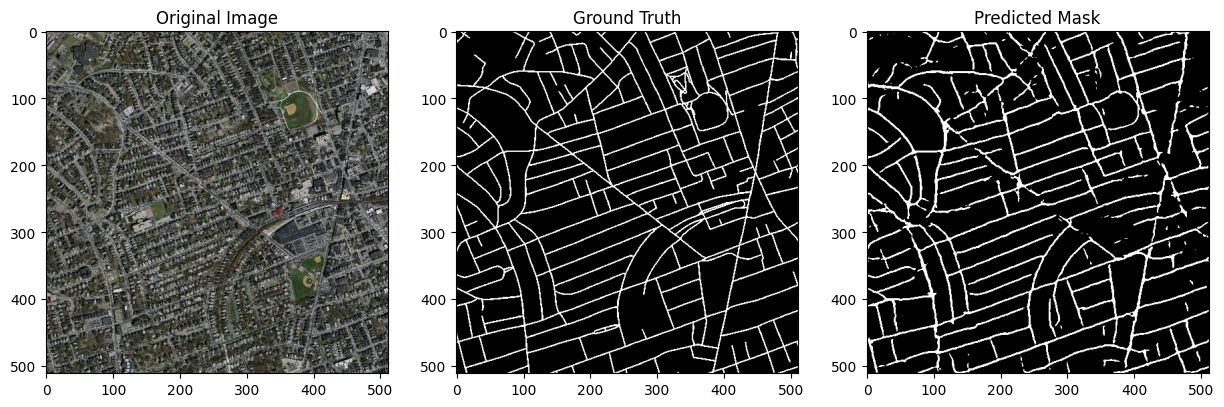

In [76]:
Utils.display_inference(image, mask, pred_mask)

#Extra documents for help


albumentation documentation : https://albumentations.ai/docs/


segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

Created by Carlos Sarasty.